# Mining Subsidence Analysis Tool

## Overview
This notebook calculates and visualizes subsidence above coal mining panels using the **Influence Template Method**. 

### Key Features:
- **Pre-computed Influence Template**: 10 rings × 64 sectors = 640 elements per panel
- **Shapely Geometry**: Efficient polygon containment checking
- **Visualization**: Subsidence contours, panel boundaries, and influence patterns
- **Scalable**: Optimized for grids with thousands of evaluation points

### Theory:
The subsidence at any surface point is calculated by:
$$S_{total} = \sum_i (w_i \cdot S_{max})$$

where $w_i$ is the weighting factor for each influence element and $S_{max} = h \times e \times a$

## Section 1: Import Required Libraries

We'll use NumPy for numerical operations, Matplotlib for visualization, Shapely for geometric operations, and the math module for trigonometric functions.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from shapely.geometry import Point, Polygon
import math

## Section 2: Gather User Inputs

Define the mining parameters and panel geometry. You can modify these values or use `input()` to collect them interactively.

**Parameters:**
- **H**: Depth of cover (meters)
- **h**: Panel thickness (meters)
- **e**: Extraction ratio (0.7 for Bord & Pillar, 1.0 for Longwall)
- **a**: Subsidence factor (dimensionless, typically 0.3–0.8)
- **NEW**: NEW ratio = W_new / H (width of new panel relative to depth)
- **alpha**: Angle of draw (degrees)
- **grid_spacing**: Mesh grid spacing (meters)

In [9]:
# Set default values for testing (you can replace with input() for interactive mode)

# Option 1: Use fixed values
H = 100.0  # Depth of cover (m)
h = 2.5    # Panel thickness (m)
e = 0.9    # Extraction ratio
a = 0.5    # Subsidence factor
NEW = 1.2  # NEW ratio
alpha_deg = 30.0  # Angle of draw (degrees)
grid_spacing = 5.0  # Mesh grid spacing (m)

# Option 2: Uncomment below for interactive input mode
# H = float(input("Enter Depth of Cover (H) in meters: "))
# h = float(input("Enter Panel Thickness (h) in meters: "))
# e = float(input("Enter Extraction Ratio (e.g., 0.7 for B&P, 1.0 for Longwall): "))
# a = float(input("Enter Subsidence Factor (a): "))
# NEW = float(input("Enter NEW ratio (W_new / H): "))
# alpha_deg = float(input("Enter Angle of draw (alpha) in degrees: "))
# grid_spacing = float(input("Enter mesh grid spacing (e.g., 5 or 10 meters): "))

# Convert angle to radians
alpha_rad = math.radians(alpha_deg)

# Calculate maximum subsidence
S_max = h * e * a

print(f"\n{'='*60}")
print(f"Mining Subsidence Analysis Parameters")
print(f"{'='*60}")
print(f"Depth of Cover (H):        {H:.2f} m")
print(f"Panel Thickness (h):       {h:.2f} m")
print(f"Extraction Ratio (e):      {e:.2f}")
print(f"Subsidence Factor (a):     {a:.2f}")
print(f"NEW Ratio:                 {NEW:.2f}")
print(f"Angle of Draw (α):         {alpha_deg:.2f}° ({alpha_rad:.4f} rad)")
print(f"Grid Spacing:              {grid_spacing:.2f} m")
print(f"Maximum Subsidence (S_max):{S_max:.4f} m")
print(f"{'='*60}\n")


Mining Subsidence Analysis Parameters
Depth of Cover (H):        100.00 m
Panel Thickness (h):       2.50 m
Extraction Ratio (e):      0.90
Subsidence Factor (a):     0.50
NEW Ratio:                 1.20
Angle of Draw (α):         30.00° (0.5236 rad)
Grid Spacing:              5.00 m
Maximum Subsidence (S_max):1.1250 m



## Section 3: Define Panel Geometry and Create Grid

Create the mining panel as a Shapely Polygon, calculate the influence radius R, and generate a 2D grid of evaluation points.

$$R = H \cdot \tan(\alpha)$$

The grid is expanded beyond the panel boundary by ±R on all sides to capture the full influence zone.

In [10]:
# Define panel coordinates (easting, northing) - example rectangular panel
# You can modify these coordinates or input from external data
panel_coords = [
    (200, 100),   # Southwest corner
    (500, 100),   # Southeast corner
    (500, 400),   # Northeast corner
    (200, 400),   # Northwest corner
]

# Create Shapely Polygon
panel_poly = Polygon(panel_coords)

# Get bounding box
min_x, min_y, max_x, max_y = panel_poly.bounds

print(f"\nPanel Geometry:")
print(f"  Panel Bounds: X=[{min_x:.1f}, {max_x:.1f}], Y=[{min_y:.1f}, {max_y:.1f}]")
print(f"  Panel Area: {panel_poly.area:.0f} m²")

# Calculate influence radius
R = H * math.tan(alpha_rad)
print(f"  Influence Radius (R): {R:.2f} m")

# Expand grid bounds by R (the influence radius)
grid_min_x = min_x - R
grid_max_x = max_x + R
grid_min_y = min_y - R
grid_max_y = max_y + R

print(f"\nGrid Bounds (expanded by R):")
print(f"  X: [{grid_min_x:.1f}, {grid_max_x:.1f}]")
print(f"  Y: [{grid_min_y:.1f}, {grid_max_y:.1f}]")

# Create 1D arrays for X and Y
x_array = np.arange(grid_min_x, grid_max_x + grid_spacing, grid_spacing)
y_array = np.arange(grid_min_y, grid_max_y + grid_spacing, grid_spacing)

# Create 2D meshgrid
X_grid, Y_grid = np.meshgrid(x_array, y_array)

print(f"  Grid Points: {len(x_array)} × {len(y_array)} = {X_grid.size} points")
print()


Panel Geometry:
  Panel Bounds: X=[200.0, 500.0], Y=[100.0, 400.0]
  Panel Area: 90000 m²
  Influence Radius (R): 57.74 m

Grid Bounds (expanded by R):
  X: [142.3, 557.7]
  Y: [42.3, 457.7]
  Grid Points: 85 × 85 = 7225 points



## Section 4: Build the Influence Template

Pre-compute an influence template centered at (0, 0) with 10 rings and 64 sectors (total 640 elements).

**Template Structure:**
- **10 Rings**: Distributed radially from 0 to R
- **64 Sectors**: Distributed azimuthally around 360°
- **Each Element**: Stores (dx, dy, weight) for later translation

For ring $i$ and sector $j$:
$$r_{mid,i} = (i + 0.5) \times \frac{R}{10}$$
$$\phi_j = j \times \frac{2\pi}{64}$$
$$dx_j = r_{mid,i} \cdot \cos(\phi_j), \quad dy_j = r_{mid,i} \cdot \sin(\phi_j)$$

In [11]:
# --- CORRECTED SECTION 4 ---

# Pre-calculated Ring Weighting Factors (S_i) from the center outwards
# These integrate the bell-shaped influence curve over the 10 rings
S_i = [0.0297, 0.0854, 0.1311, 0.1607, 0.1708, 0.1596, 0.1294, 0.0859, 0.0397, 0.0069]

num_rings = 10
num_sectors = 64
template_elements = []

# For each ring
for i in range(num_rings):
    # Calculate mid-radius for this ring
    r_mid = (i + 0.5) * (R / num_rings)

    # Calculate the element weight for this specific ring
    weight = S_i[i] / num_sectors

    # For each sector
    for j in range(num_sectors):
        # Calculate angle
        phi = j * (2 * np.pi / num_sectors)

        # Local coordinates relative to origin
        dx = r_mid * np.cos(phi)
        dy = r_mid * np.sin(phi)

        template_elements.append((dx, dy, weight))

print(f"Influence Template Built:")
print(f"  Total Elements: {len(template_elements)}")
print(f"  Rings: {num_rings}, Sectors: {num_sectors}")
print(f"  Sum of all weights (Should be 1.0): {sum([w for x, y, w in template_elements]):.4f}")
print(f"  Max Radius: {R:.2f} m\n")

Influence Template Built:
  Total Elements: 640
  Rings: 10, Sectors: 64
  Sum of all weights (Should be 1.0): 0.9992
  Max Radius: 57.74 m



## Section 5: Execute Main Calculation Engine

Loop through every grid point and apply the influence template. For each template element shifted to the grid point location, check if it falls within the panel using Shapely's `contains()` method.

**Algorithm:**
1. For each grid point $(X_p, Y_p)$:
2.     Initialize point_subsidence = 0
3.     For each template element (dx, dy, weight):
4.         Translate element: $(x_{elem}, y_{elem}) = (X_p + dx, Y_p + dy)$
5.         If panel contains $(x_{elem}, y_{elem})$:
6.             Accumulate: point_subsidence += weight × $S_{max}$
7.     Store result: $(X_p, Y_p, \text{point\_subsidence})$

In [12]:
import time

# Main calculation: loop through all grid points
results = []
total_points = X_grid.size

print("Starting Subsidence Calculation...")
print(f"Evaluating {total_points} grid points...\n")

start_time = time.time()

# Flatten the grid arrays
X_flat = X_grid.flatten()
Y_flat = Y_grid.flatten()

# Process each grid point
for idx, (X_p, Y_p) in enumerate(zip(X_flat, Y_flat)):
    point_subsidence = 0.0
    
    # Check all template elements
    for dx, dy, weight in template_elements:
        # Translate template element to current grid point
        element_x = X_p + dx
        element_y = Y_p + dy
        
        # Create point at this location
        pt = Point(element_x, element_y)
        
        # Check if point is inside the panel
        if panel_poly.contains(pt):
            # This element contributes to subsidence
            point_subsidence += weight * S_max
    
    # Store result
    results.append((X_p, Y_p, point_subsidence))
    
    # Progress indicator
    if (idx + 1) % max(1, total_points // 10) == 0:
        elapsed = time.time() - start_time
        percent = 100 * (idx + 1) / total_points
        est_total = elapsed / ((idx + 1) / total_points)
        est_remaining = est_total - elapsed
        print(f"  {percent:5.1f}% ({idx+1:6d}/{total_points}) - "
              f"Elapsed: {elapsed:6.1f}s, Remaining: ~{est_remaining:6.1f}s")

elapsed_time = time.time() - start_time
print(f"\nCalculation Complete!")
print(f"  Total Time: {elapsed_time:.2f} seconds")
print(f"  Points/sec: {total_points/elapsed_time:.0f}\n")

Starting Subsidence Calculation...
Evaluating 7225 grid points...

   10.0% (   722/7225) - Elapsed:    5.5s, Remaining: ~  49.5s
   20.0% (  1444/7225) - Elapsed:   11.3s, Remaining: ~  45.2s
   30.0% (  2166/7225) - Elapsed:   17.4s, Remaining: ~  40.7s
   40.0% (  2888/7225) - Elapsed:   23.6s, Remaining: ~  35.4s
   50.0% (  3610/7225) - Elapsed:   29.6s, Remaining: ~  29.7s
   60.0% (  4332/7225) - Elapsed:   35.9s, Remaining: ~  24.0s
   70.0% (  5054/7225) - Elapsed:   42.0s, Remaining: ~  18.1s
   79.9% (  5776/7225) - Elapsed:   48.2s, Remaining: ~  12.1s
   89.9% (  6498/7225) - Elapsed:   54.0s, Remaining: ~   6.0s
   99.9% (  7220/7225) - Elapsed:   59.5s, Remaining: ~   0.0s

Calculation Complete!
  Total Time: 59.57 seconds
  Points/sec: 121



## Section 6: Extract and Prepare Results Data

Convert 1D results list into 2D grids compatible with Matplotlib's contouring functions.

In [13]:
import pandas as pd

# Convert results to a DataFrame for easy viewing and exporting
df_results = pd.DataFrame(results, columns=['Easting_X', 'Northing_Y', 'Subsidence_S'])

# Filter out points with zero subsidence to keep the data clean (optional)
df_impacted = df_results[df_results['Subsidence_S'] > 0.001].copy()

print("Sample of Calculated Points (Easting, Northing, Subsidence):")
print(df_impacted.head(15).to_string(index=False))
print(f"\nTotal points with subsidence: {len(df_impacted)} / {len(df_results)}")

# Save to CSV so you can view it in Excel or use it in other software
df_results.to_csv('subsidence_results.csv', index=False)
print("\nAll point values have been saved to 'subsidence_results.csv'")

Sample of Calculated Points (Easting, Northing, Subsidence):
 Easting_X  Northing_Y  Subsidence_S
192.264973   52.264973      0.001183
197.264973   52.264973      0.002002
202.264973   52.264973      0.002821
207.264973   52.264973      0.003640
212.264973   52.264973      0.004460
217.264973   52.264973      0.004581
222.264973   52.264973      0.004702
227.264973   52.264973      0.004823
232.264973   52.264973      0.004823
237.264973   52.264973      0.004823
242.264973   52.264973      0.004823
247.264973   52.264973      0.004823
252.264973   52.264973      0.004823
257.264973   52.264973      0.004823
262.264973   52.264973      0.004823

Total points with subsidence: 6296 / 7225

All point values have been saved to 'subsidence_results.csv'


## Section 7: Visualize Subsidence Trough and Influence Pattern

Create a comprehensive visualization showing:
1. **Panel boundary** (black outline)
2. **Filled contour plot** of subsidence using reversed colormap
3. **Grid boundary box** (dashed line)
4. **Influence circle diagram** with 10 concentric rings and 64 sectors

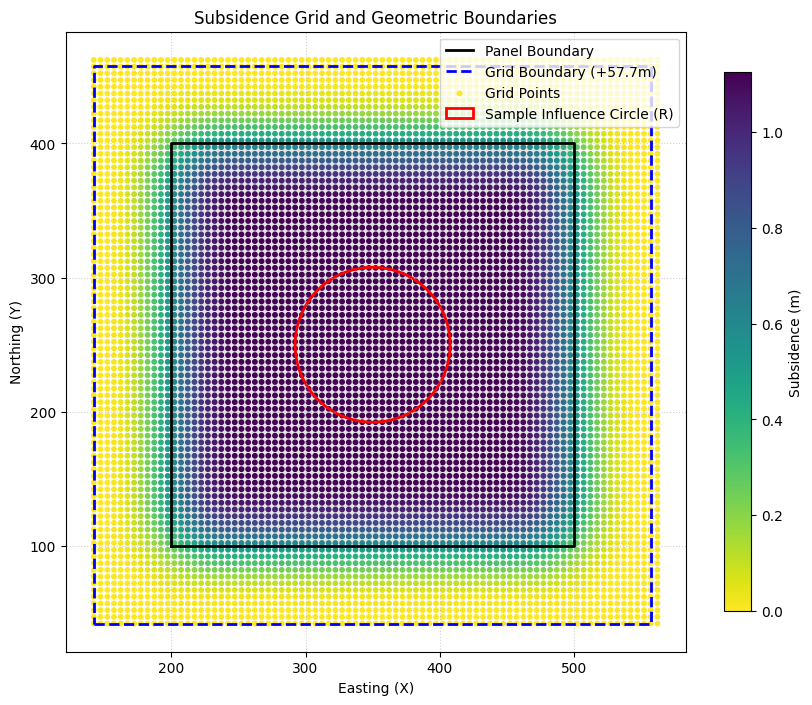

In [14]:
# --- REVISED SECTION 7 ---
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(10, 10))

# 1. Draw Panel Boundary
panel_x, panel_y = panel_poly.exterior.xy
ax.plot(panel_x, panel_y, color='black', linewidth=2, label='Panel Boundary')
ax.fill(panel_x, panel_y, alpha=0.2, color='gray') # Light shade for the extracted area

# 2. Draw Grid Boundary (Expanded by R = H*tan(alpha))
rect_x = [grid_min_x, grid_max_x, grid_max_x, grid_min_x, grid_min_x]
rect_y = [grid_min_y, grid_min_y, grid_max_y, grid_max_y, grid_min_y]
ax.plot(rect_x, rect_y, 'b--', linewidth=2, label=f'Grid Boundary (+{R:.1f}m)')

# 3. Draw the Grid Points
# Using a scatter plot where the color indicates the amount of subsidence
sc = ax.scatter(df_results['Easting_X'], df_results['Northing_Y'], 
                c=df_results['Subsidence_S'], cmap='viridis_r', s=10, label='Grid Points')
plt.colorbar(sc, label='Subsidence (m)', shrink=0.7)

# 4. Draw a Sample Influence Circle
# We will draw it at the center of the panel to demonstrate the r = H*tan(alpha) radius
center_x = (min_x + max_x) / 2
center_y = (min_y + max_y) / 2
sample_circle = Circle((center_x, center_y), R, color='red', fill=False, 
                       linestyle='-', linewidth=2, label='Sample Influence Circle (R)')
ax.add_patch(sample_circle)

# Formatting
ax.set_aspect('equal')
ax.set_xlabel('Easting (X)')
ax.set_ylabel('Northing (Y)')
ax.set_title('Subsidence Grid and Geometric Boundaries')
ax.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Summary & Results Interpretation

### Key Outputs:
- **S_max**: Maximum possible subsidence = h × e × a
- **Influence Radius (R)**: H × tan(α) — the zone where the panel affects surface
- **Grid Points**: Total evaluation locations for subsidence calculation
- **Calculation Speed**: Demonstrates the efficiency of the pre-computed template method

### Output Files:
- **subsidence_visualization.png**: Main visualization showing contours and influence pattern

### How to Use This Notebook:
1. **Modify Panel Coordinates**: Edit `panel_coords` to define your mining panel geometry
2. **Adjust Parameters**: Change H, h, e, a, NEW, alpha_deg, grid_spacing as needed
3. **Switch to Interactive Mode**: Uncomment the `input()` calls in Section 2 for terminal input
4. **Run All Cells**: Execute the entire notebook to see results
5. **Export Results**: Use numpy/pandas to save subsidence data to CSV/Excel if needed

### Advanced Extensions:
- Implement the **Modified Method** with distance-based weighting
- Add multiple panel support (loop template over multiple panels)
- Export 3D data for GIS visualization
- Implement probabilistic approaches
- Add validation against field measurements

### References:
- Influence Function Method: Widely used in mining subsidence prediction
- NEW Ratio: Newer and Kratzsch Method
- Angle of Draw: 20°–40° typical for coal mining